TRAINING n VALIDATION OF MODEL

Data normalization to account for contrast variations in satellite imagery

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import zarr
import numpy as np
import matplotlib.pyplot as plt
import rasterio 


zarr_path = r"C:\Users\mvens\Documents\projets\binary_classifier_forest\dataset_ndvi.zarr"

In [2]:
#STEP 1: DATASET DEFINITION
class forestZarrDataset(Dataset):
    def __init__(self, zarr_path):
        self.root = zarr.open(zarr_path, mode='r')
        self.forest = self.root['forest']
        self.not_forest = self.root['not_forest']
        self.n_forest = self.forest.shape[0]
        self.n_not_forest = self.not_forest.shape[0]

    def __len__(self):
        return self.n_forest + self.n_not_forest

    def __getitem__(self, idx):
        if idx < self.n_forest:
            patch = self.forest[idx]
            label = 1.0
        else:
            patch = self.not_forest[idx - self.n_forest]
            label = 0.0
        
        #CRITICAL DATA CLEANING
        #1. Handle NaNs and infinite values using NumPy
        #Replaces NaN with 0.0 and caps infinities
        patch = np.nan_to_num(patch, nan=0.0, posinf=1.0, neginf=-1.0)
        
        #2. Convert to PyTorch Tensor
        #Adds a channel dimension (C, H, W) and sets type to float32
        patch = torch.from_numpy(patch).float().unsqueeze(0)
        label = torch.tensor(label).float()
        
        return patch, label

In [3]:
#STEP 2: CNN MODEL ARCHITECTURE
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        #First layer: Detects edges and basic textures
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(2) # Divise la taille par 2 (32 -> 16)
        
        #Second layer: Detects more complex patterns and features
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        #After two pooling layers, the feature map size is 8x8 pixels
        #Fully connected layers (Dense layers)
        self.fc1 = nn.Linear(32 * 8 * 8, 64)
        self.fc2 = nn.Linear(64, 1) #Single output (Binary classification)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        #Feature extraction phase
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(-1, 32 * 8 * 8) #Flatten the output for the dense layers

        #Classification phase
        x = self.relu(self.fc1(x))
        x = self.sigmoid(self.fc2(x))
        return x


In [4]:
 #STEP 3: PIPELINE SETUP
dataset = forestZarrDataset(zarr_path)

#80/20 Train/Validation Split
#Dividing the 1000 samples into 800 for training and 200 for validation
train_set, val_set = random_split(dataset, [800, 200])

#DataLoaders: Efficient batch management and shuffling
train_loader = DataLoader(train_set, batch_size=16, shuffle=True)
val_loader = DataLoader(val_set, batch_size=16, shuffle=False)

#Model initialization
model = SimpleCNN()

#Loss function and Optimizer (Hyperparameters)
criterion = nn.BCELoss() # Binary Cross Entropy
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("Model and DataLoaders ready for training!")

Model and DataLoaders ready for training!


In [5]:
# Check min and max values

# Open the Zarr storage
root = zarr.open(zarr_path, mode='r')

for label in ['forest', 'not_forest']:
    # Load data into memory for statistical analysis
    # [:] loads the entire array, allowing NumPy to process it
    raw_data = root[label][:]
    
    print(f"--- Summary Statistics for {label} (ignoring NaNs) ---")
    
    # Using NumPy's "NaN-safe" functions
    v_min = np.nanmin(raw_data)
    v_max = np.nanmax(raw_data)
    v_mean = np.nanmean(raw_data)
    v_med = np.nanmedian(raw_data)
    
    print(f"Min:      {v_min:.4f}")
    print(f"Max:      {v_max:.4f}")
    print(f"Mean:     {v_mean:.4f}")
    print(f"Median:   {v_med:.4f}")
    print(f"Shape:    {raw_data.shape}")
    
    # Bonus: Data integrity check (Counting corrupted pixels)
    nan_count = np.isnan(raw_data).sum()
    total_pixels = raw_data.size
    print(f"Corrupted Pixels (NaN): {nan_count} ({100*nan_count/total_pixels:.2f}%)")
    print("-" * 40)

--- Summary Statistics for forest (ignoring NaNs) ---
Min:      -0.3671
Max:      0.9273
Mean:     0.6315
Median:   0.6555
Shape:    (500, 32, 32)
Corrupted Pixels (NaN): 426 (0.08%)
----------------------------------------
--- Summary Statistics for not_forest (ignoring NaNs) ---
Min:      -0.6210
Max:      0.9001
Mean:     0.4182
Median:   0.4411
Shape:    (500, 32, 32)
Corrupted Pixels (NaN): 3824 (0.75%)
----------------------------------------


In [6]:
#DEVICE CONFIGURATION
#Detect GPU availability, otherwise fallback to CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleCNN().to(device)

#HYPERPARAMETERS & CRITERION
#Optimizer (the corrector) and Loss Function (the rulebook)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.BCELoss()

num_epochs = 20 #Number of full passes through the dataset

print(f"Lancement de l'entraînement sur : {device}")

#Dictionary to store performance metrics
history = {
    'train_loss': [],
    'val_acc': []
}

#MAIN TRAINING LOOP
for epoch in range(num_epochs):
    #1. TRAINING MODE
    model.train()
    running_loss = 0.0
    
    for images, labels in train_loader:
        #Move tensors to the configured device
        images, labels = images.to(device), labels.to(device)

        #Reset gradients to zero for every batch
        optimizer.zero_grad()
    
        #Safety: use view(-1) instead of squeeze() to match label shape exactly
        outputs = model(images).view(-1) 
        #Calculate the loss
        loss = criterion(outputs, labels)
    
        #Crash prevention check
        if torch.isnan(loss):
            print("Alerte : La perte est encore NaN !")
            continue 
    #Backward pass: compute gradients
    loss.backward()
    #Optimizer step: update model weights
    optimizer.step()
    running_loss += loss.item()

    # 2.VALIDATION MODE (Evaluation without weight updates)
    model.eval()
    val_correct = 0
    val_total = 0
    
    with torch.no_grad(): #Disable gradient calculation for efficiency and memory saving
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images).squeeze()
            
            #Thresholding: score > 0.5 is forest (1), else non-forest (0)
            predictions = (outputs > 0.5).float()
            val_total += labels.size(0)
            val_correct += (predictions == labels).sum().item()

    #PROGRESS TRACKING
    epoch_loss = running_loss / len(train_loader)
    accuracy = 100 * val_correct / val_total

    #Log the metrics
    history['train_loss'].append(epoch_loss)
    history['val_acc'].append(accuracy)
    print(f"Epoch [{epoch+1}/{num_epochs}] | Loss: {epoch_loss:.4f} | Accuracy: {accuracy:.2f}%")

print("\nEntraînement terminé !")

Lancement de l'entraînement sur : cuda
Epoch [1/20] | Loss: 0.0146 | Accuracy: 56.50%
Epoch [2/20] | Loss: 0.0137 | Accuracy: 53.50%
Epoch [3/20] | Loss: 0.0125 | Accuracy: 53.50%
Epoch [4/20] | Loss: 0.0146 | Accuracy: 53.50%
Epoch [5/20] | Loss: 0.0142 | Accuracy: 53.50%
Epoch [6/20] | Loss: 0.0133 | Accuracy: 55.50%
Epoch [7/20] | Loss: 0.0140 | Accuracy: 48.00%
Epoch [8/20] | Loss: 0.0138 | Accuracy: 48.00%
Epoch [9/20] | Loss: 0.0137 | Accuracy: 73.50%
Epoch [10/20] | Loss: 0.0135 | Accuracy: 80.00%
Epoch [11/20] | Loss: 0.0136 | Accuracy: 66.50%
Epoch [12/20] | Loss: 0.0135 | Accuracy: 61.00%
Epoch [13/20] | Loss: 0.0131 | Accuracy: 59.50%
Epoch [14/20] | Loss: 0.0126 | Accuracy: 56.00%
Epoch [15/20] | Loss: 0.0125 | Accuracy: 55.00%
Epoch [16/20] | Loss: 0.0139 | Accuracy: 56.00%
Epoch [17/20] | Loss: 0.0140 | Accuracy: 59.00%
Epoch [18/20] | Loss: 0.0126 | Accuracy: 73.50%
Epoch [19/20] | Loss: 0.0125 | Accuracy: 63.00%
Epoch [20/20] | Loss: 0.0125 | Accuracy: 48.00%

Entraînem

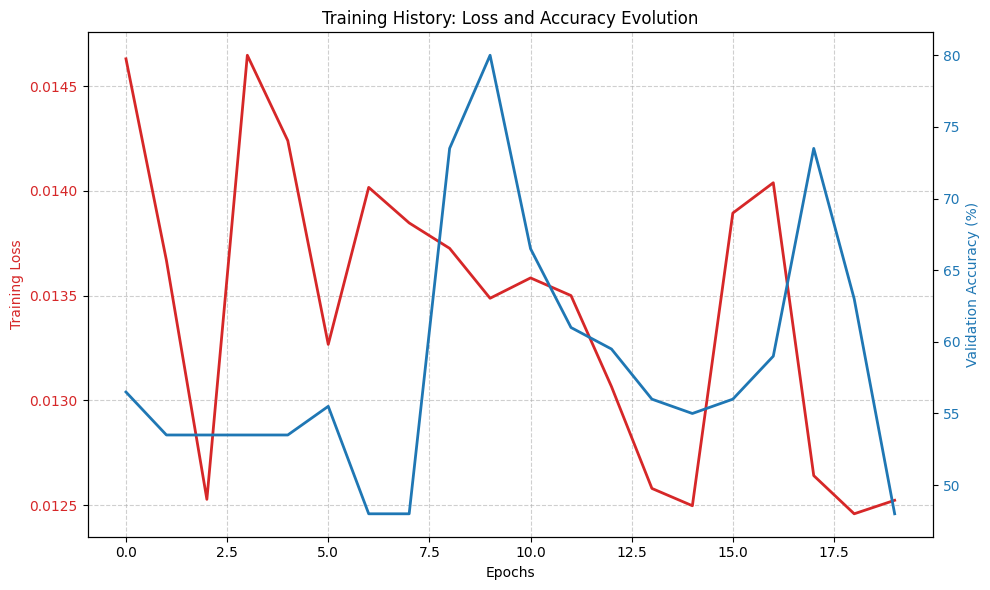

In [7]:
def plot_training_history(history):
    """
    Plots the training loss and validation accuracy across epochs.
    """
    fig, ax1 = plt.subplots(figsize=(10, 6))

    #First axis: Training Loss (in red)
    color = 'tab:red'
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Training Loss', color=color)
    ax1.plot(history['train_loss'], color=color, linewidth=2, label='Loss')
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.grid(True, linestyle='--', alpha=0.6)

    #Second axis: Validation Accuracy (in blue)
    #Create a twin axis sharing the same X-axis
    ax2 = ax1.twinx() 
    color = 'tab:blue'
    ax2.set_ylabel('Validation Accuracy (%)', color=color)
    ax2.plot(history['val_acc'], color=color, linewidth=2, label='Accuracy')
    ax2.tick_params(axis='y', labelcolor=color)

    #Title and final layout
    plt.title('Training History: Loss and Accuracy Evolution')
    fig.tight_layout()
    plt.show()

#Call the function
plot_training_history(history)

In [8]:
#RE-RUN TRAINING AND SAVE MODEL

#Set optimal number of epochs based on previous history
num_epochs = 18 

print(f"Starting training on: {device}")

#MAIN TRAINING LOOP
for epoch in range(num_epochs):
    #1. TRAINING PHASE
    model.train()
    running_loss = 0.0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
    
        optimizer.zero_grad()
    
        #Use view(-1) to ensure output matches label shape for BCELoss
        outputs = model(images).view(-1) 
    
        loss = criterion(outputs, labels)
    
        #Safety check to prevent training collapse
        if torch.isnan(loss):
            print("Alert: Loss is NaN! Skipping batch...")
            continue 

        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    # 2.VALIDATION PHASE (Evaluation mode)
    model.eval()
    val_correct = 0
    val_total = 0
    
    with torch.no_grad(): #Disable gradient tracking for inference
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images).squeeze()
            
            #Binary threshold: 0.5
            predictions = (outputs > 0.5).float()
            val_total += labels.size(0)
            val_correct += (predictions == labels).sum().item()

    #LOGGING RESULTS
    epoch_loss = running_loss / len(train_loader)
    accuracy = 100 * val_correct / val_total
    
    history['train_loss'].append(epoch_loss)
    history['val_acc'].append(accuracy)
    print(f"Epoch [{epoch+1}/{num_epochs}] | Loss: {epoch_loss:.4f} | Accuracy: {accuracy:.2f}%")

print("\nTraining Complete!")

#SAVE MODEL WEIGHTS
#Saving the state_dict (recommended practice in PyTorch)
model_path = "forest_classification_model.pth"
torch.save(model.state_dict(), model_path)
print(f"Model saved successfully to: {model_path}")

Starting training on: cuda
Epoch [1/18] | Loss: 0.4873 | Accuracy: 80.00%
Epoch [2/18] | Loss: 0.3851 | Accuracy: 83.00%
Epoch [3/18] | Loss: 0.3426 | Accuracy: 85.50%
Epoch [4/18] | Loss: 0.2928 | Accuracy: 84.50%
Epoch [5/18] | Loss: 0.2774 | Accuracy: 86.50%
Epoch [6/18] | Loss: 0.2713 | Accuracy: 86.00%
Epoch [7/18] | Loss: 0.2390 | Accuracy: 87.00%
Epoch [8/18] | Loss: 0.2449 | Accuracy: 87.00%
Epoch [9/18] | Loss: 0.2243 | Accuracy: 86.50%
Epoch [10/18] | Loss: 0.2174 | Accuracy: 88.00%
Epoch [11/18] | Loss: 0.2003 | Accuracy: 88.00%
Epoch [12/18] | Loss: 0.1909 | Accuracy: 87.00%
Epoch [13/18] | Loss: 0.2023 | Accuracy: 90.00%
Epoch [14/18] | Loss: 0.1803 | Accuracy: 89.50%
Epoch [15/18] | Loss: 0.1782 | Accuracy: 87.50%
Epoch [16/18] | Loss: 0.2223 | Accuracy: 88.00%
Epoch [17/18] | Loss: 0.1584 | Accuracy: 88.00%
Epoch [18/18] | Loss: 0.1443 | Accuracy: 90.50%

Training Complete!
Model saved successfully to: forest_classification_model.pth


In [11]:
def apply_fine_model(model, image_path, device, patch_size=32, stride=8):
    """
    Applies the model across the entire image using a sliding window 
    with overlap to create a smooth probability map.
    """
    with rasterio.open(image_path) as src:
        data = src.read(1)
        h, w = data.shape
        
    #1. Initialize maps to store accumulated probabilities and hit counts
    #somme_probs: stores the sum of predicted probabilities per pixel
    #hit_counter: counts how many times each pixel was covered by a patch
    prob_sum = np.zeros((h, w))
    hit_counter = np.zeros((h, w))
    
    model.eval()
    print(f"Running fine-grained inference (stride={stride})...")
    
    with torch.no_grad():
        #Sliding window loops
        #Using a stride smaller than the patch_size creates overlap for smoothing
        for i in range(0, h - patch_size, stride):
            for j in range(0, w - patch_size, stride):
                #Patch Extraction
                patch = data[i:i+patch_size, j:j+patch_size]
                patch = np.nan_to_num(patch, nan=0.0)
                
                #Model Prediction
                #Adding batch and channel dimensions: (1, 1, patch_size, patch_size)
                input_tensor = torch.from_numpy(patch).float().unsqueeze(0).unsqueeze(0).to(device)
                prob = model(input_tensor).view(-1).item()
                
                #Accumulate probability across all pixels covered by the current patch
                prob_sum[i:i+patch_size, j:j+patch_size] += prob
                hit_counter[i:i+patch_size, j:j+patch_size] += 1
                
    #2. Compute the average probability map (Smoothes transitions)
    #Avoid division by zero for unvisited pixels
    avg_map = np.divide(prob_sum, hit_counter, 
                        out=np.zeros_like(prob_sum), 
                        where=hit_counter != 0)
    
    #3. Apply final threshold for binary classification (0 or 1)
    final_map = (avg_map > 0.5).astype(np.uint8)
    
    return final_map

Processing year 2020 with high resolution (Stride 1)...
Running fine-grained inference (stride=1)...


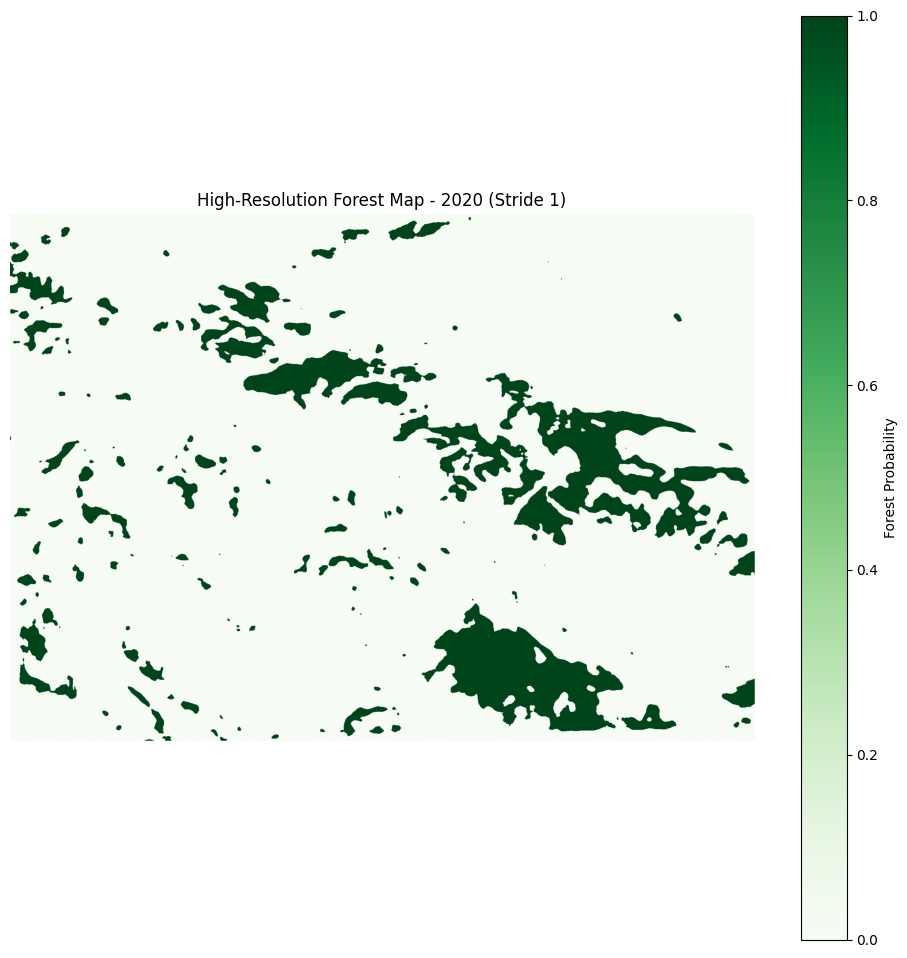

Processing year 2024 with high resolution (Stride 1)...
Running fine-grained inference (stride=1)...


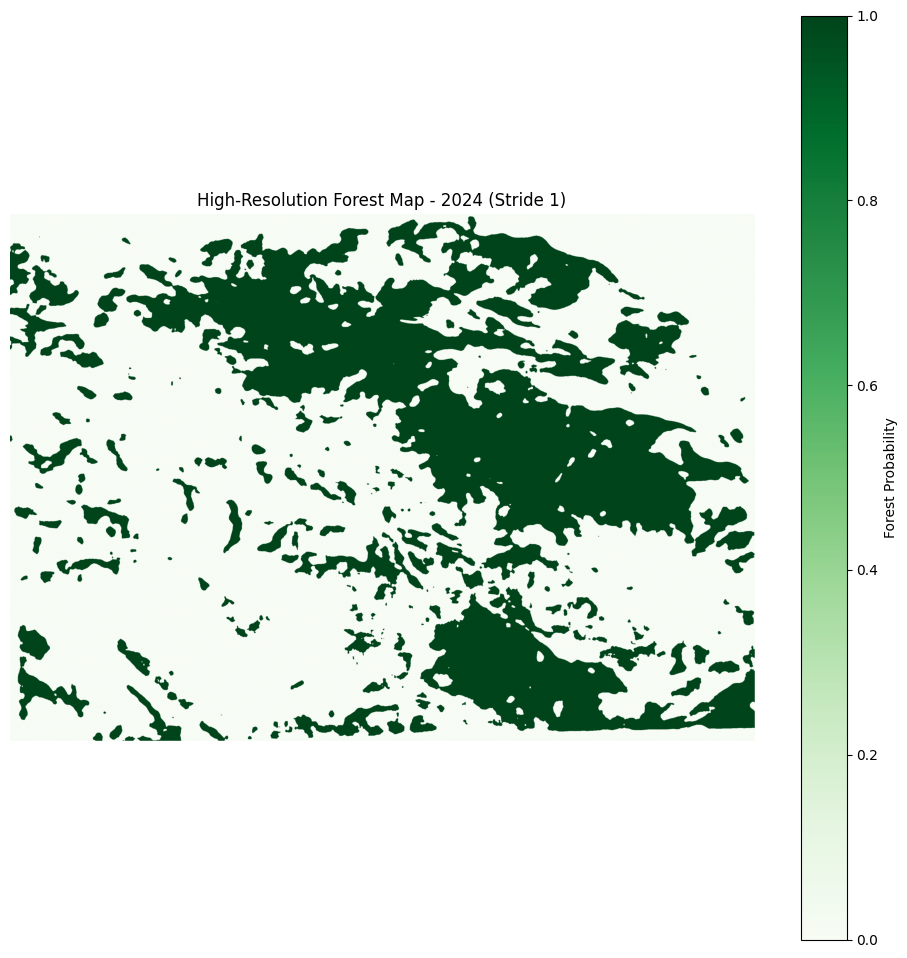

In [12]:
#EXECUTION & VISUALIZATION
#Stride = 1 means the window moves 1 pixel at a time, 
#resulting in maximum resolution/smoothness.

paths = {
    "2020": r"C:\Users\mvens\Documents\projets\binary_classifier_forest\S2_NDVI_DrySeason_2020.tif",
    "2024": r"C:\Users\mvens\Documents\projets\binary_classifier_forest\S2_NDVI_DrySeason_2024.tif"
}

results = {}

for year, path in paths.items():
    print(f"Processing year {year} with high resolution (Stride 1)...")
    
    #1. Run the model inference
    #Nota Bene: Make sure the function signature matches (model, path, device, etc.)
    fine_map = apply_fine_model(model, path, device, patch_size=32, stride=1)
    
    # 2. Store the result
    results[year] = fine_map
    
    # 3. Plot the result
    plt.figure(figsize=(12, 12))
    plt.imshow(fine_map, cmap='Greens')
    plt.title(f"High-Resolution Forest Map - {year} (Stride 1)")
    plt.colorbar(label='Forest Probability')
    plt.axis('off')
    plt.show()

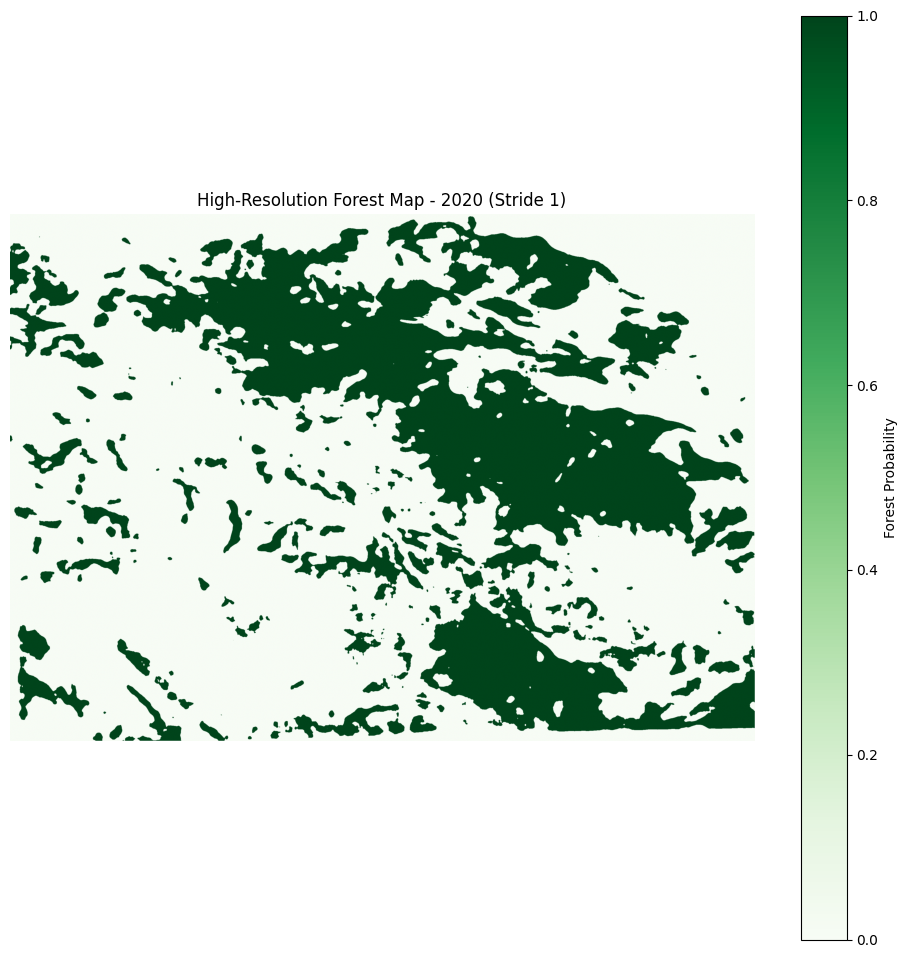

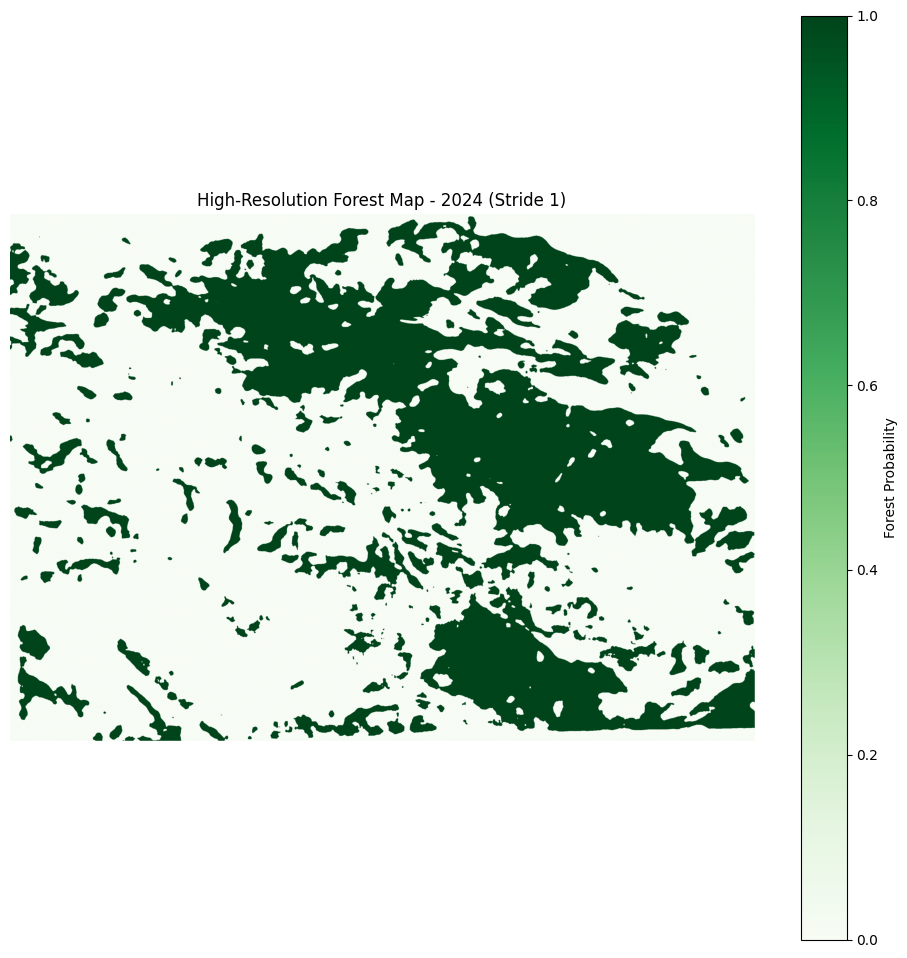

In [13]:
for year, path in paths.items():
    plt.figure(figsize=(12, 12))
    plt.imshow(fine_map, cmap='Greens')
    plt.title(f"High-Resolution Forest Map - {year} (Stride 1)")
    plt.colorbar(label='Forest Probability')
    plt.axis('off')
    plt.show()

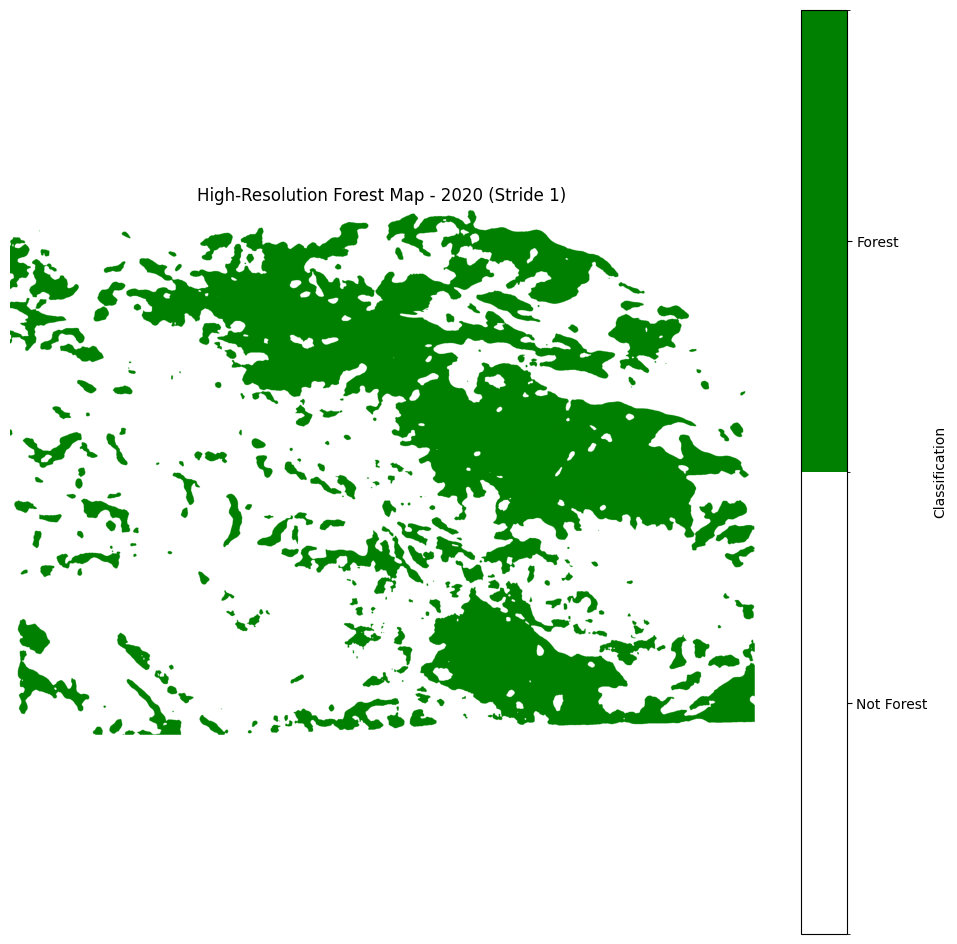

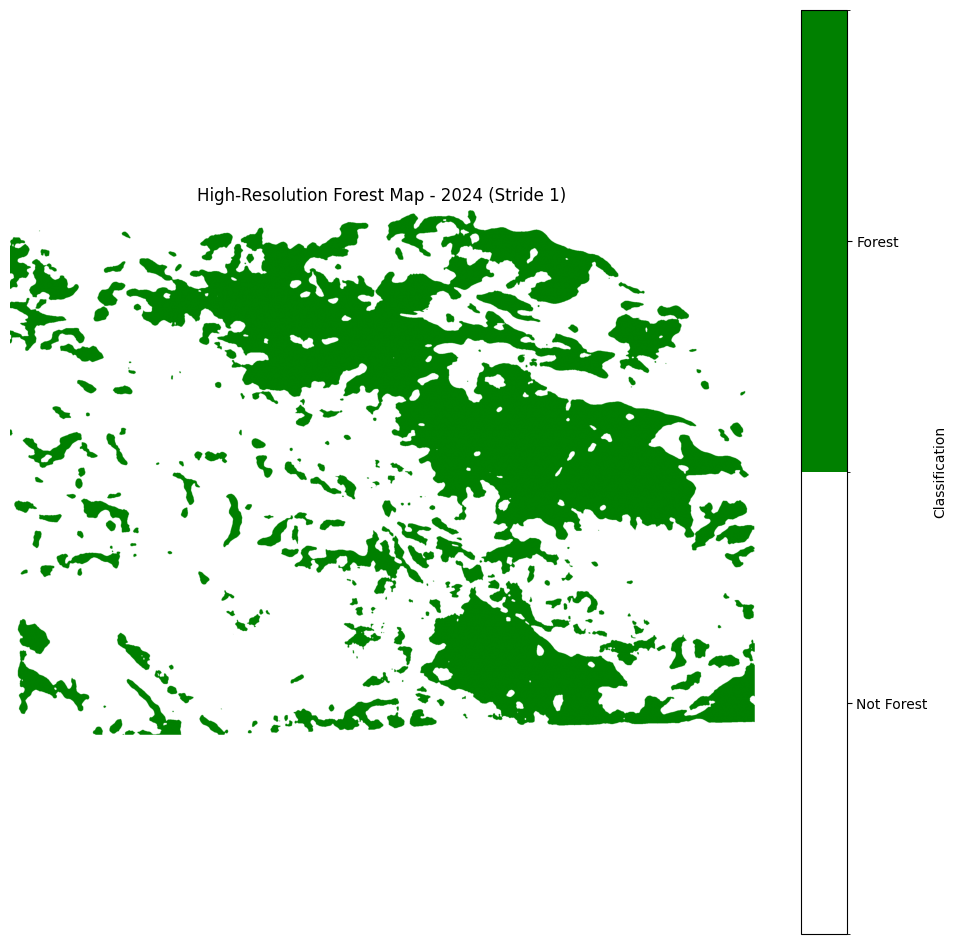

In [14]:
from matplotlib import colors

# 1. Define the discrete colors: White for background, Green for Forest
cmap_discrete = colors.ListedColormap(['white', 'green'])

# 2. Define the boundaries: 0 to 0.5 is White, 0.5 to 1.0 is Green
bounds = [0, 0.5, 1]
norm = colors.BoundaryNorm(bounds, cmap_discrete.N)

for year, path in paths.items():
    plt.figure(figsize=(12, 12))
    
    # Apply the new cmap and norm here
    im = plt.imshow(fine_map, cmap=cmap_discrete, norm=norm)
    
    plt.title(f"High-Resolution Forest Map - {year} (Stride 1)")
    
    # 3. Format the colorbar to show discrete labels
    cbar = plt.colorbar(im, ticks=[0.25, 0.75], label='Classification')
    cbar.ax.set_yticklabels(['Not Forest', 'Forest'])
    
    plt.axis('off')
    plt.show()